In [272]:
import numpy as np
import pandas as pd
import seaborn as sns

In [273]:
df = sns.load_dataset('iris')

In [274]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [275]:
from sklearn.preprocessing import LabelEncoder

In [276]:
encoder = LabelEncoder()
df['species']=encoder.fit_transform(df['species'])

In [277]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [278]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [279]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [280]:
import seaborn as sns
import matplotlib.pyplot as plt

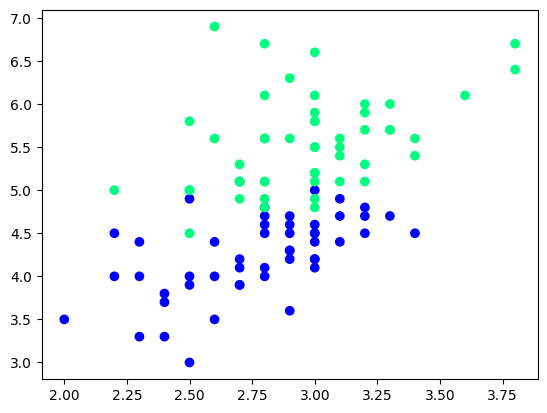

In [281]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [282]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [283]:
df_train

,sepal_width,petal_length,species
136,3.4,5.6,2
57,2.4,3.3,1
103,2.9,5.6,2
145,3.0,5.2,2
59,2.7,3.9,1
85,3.4,4.5,1
140,3.1,5.6,2
138,3.0,4.8,2
71,2.8,4.0,1
125,3.2,6.0,2


In [284]:
df_test

,sepal_width,petal_length,species
132,2.8,5.6,2
83,2.7,5.1,1
142,2.7,5.1,2
134,2.6,5.6,2
80,2.4,3.8,1


In [285]:
df_val

,sepal_width,petal_length,species
106,2.5,4.5,2
66,3.0,4.5,1
72,2.5,4.9,1
81,2.4,3.7,1
92,2.6,4.0,1


In [286]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# Case 1 - Bagging

In [287]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
71,2.8,4.0,1
103,2.9,5.6,2
138,3.0,4.8,2
85,3.4,4.5,1
140,3.1,5.6,2
125,3.2,6.0,2
85,3.4,4.5,1
59,2.7,3.9,1


In [288]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [289]:
dt_bag1 = DecisionTreeClassifier()

In [290]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

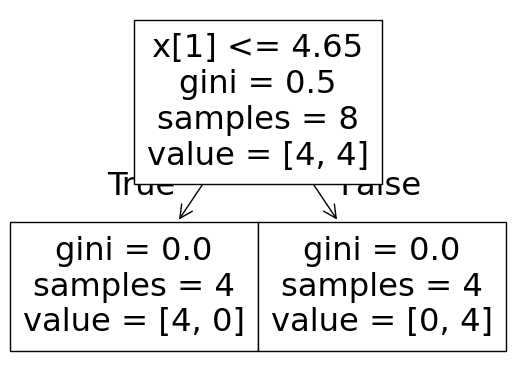

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


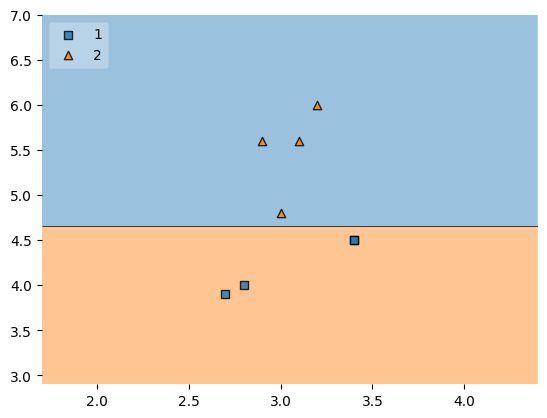

In [291]:
evaluate(dt_bag1,X,y)

In [292]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
125,3.2,6.0,2
59,2.7,3.9,1
140,3.1,5.6,2
140,3.1,5.6,2
85,3.4,4.5,1
71,2.8,4.0,1
140,3.1,5.6,2
85,3.4,4.5,1


In [293]:
dt_bag2 = DecisionTreeClassifier()

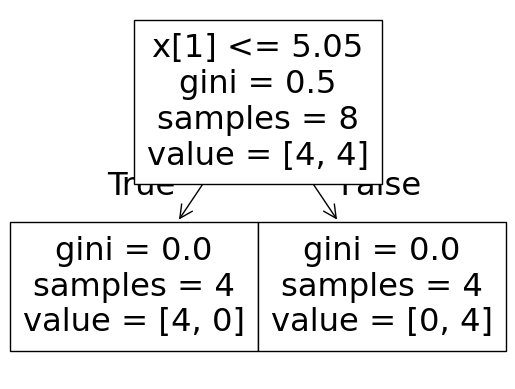

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


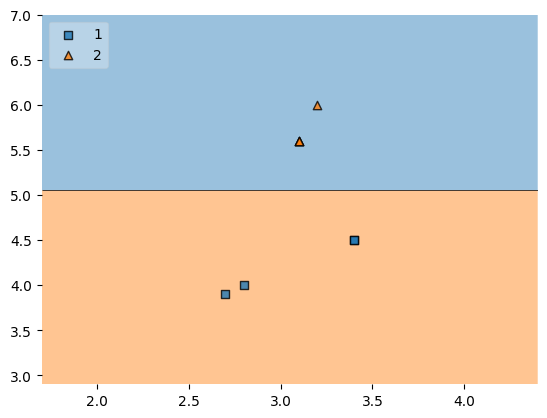

In [294]:
evaluate(dt_bag2,X,y)

In [295]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
103,2.9,5.6,2
138,3.0,4.8,2
140,3.1,5.6,2
85,3.4,4.5,1
57,2.4,3.3,1
145,3.0,5.2,2
59,2.7,3.9,1
125,3.2,6.0,2


In [296]:
dt_bag3 = DecisionTreeClassifier()

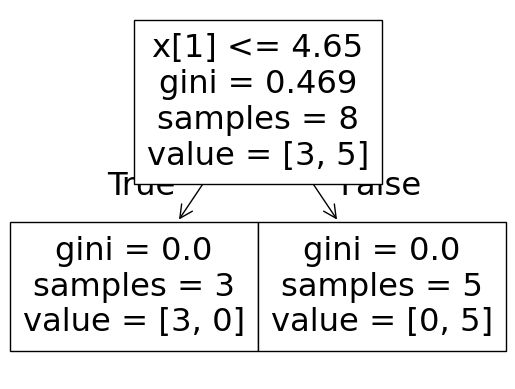

0.6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


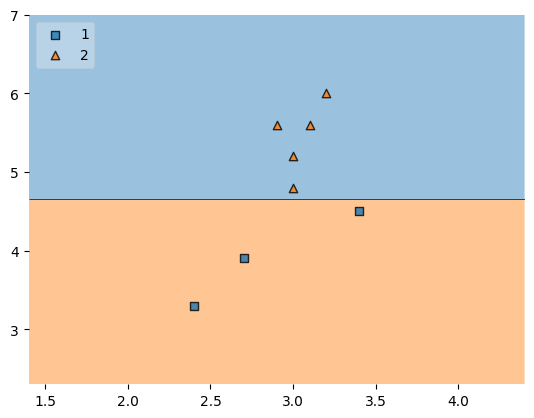

In [297]:
evaluate(dt_bag3,X,y)

In [298]:
df_bag=df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_length,species
138,3.0,4.8,2
59,2.7,3.9,1
145,3.0,5.2,2
57,2.4,3.3,1
125,3.2,6.0,2
71,2.8,4.0,1
145,3.0,5.2,2
138,3.0,4.8,2


In [299]:
dt_bag4 = DecisionTreeClassifier()

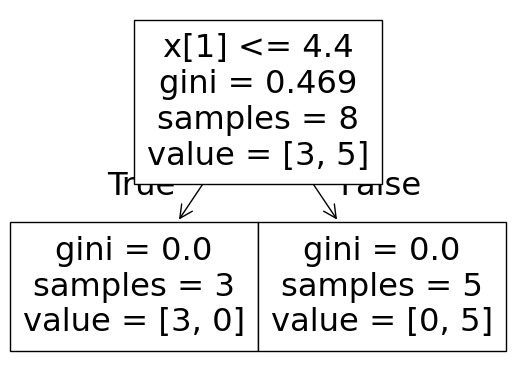

0.6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


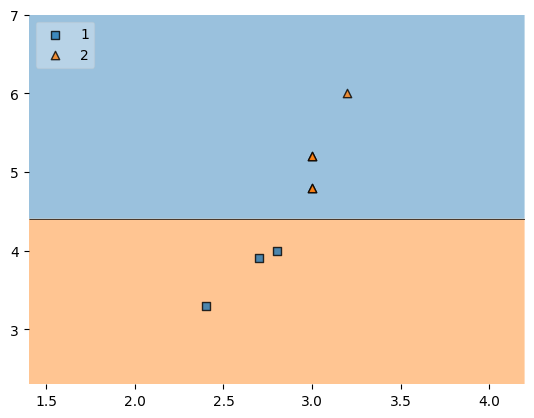

In [300]:
evaluate(dt_bag4,X,y)

In [301]:
df_test

,sepal_width,petal_length,species
132,2.8,5.6,2
83,2.7,5.1,1
142,2.7,5.1,2
134,2.6,5.6,2
80,2.4,3.8,1


In [302]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,4.9]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,4.9]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,4.9]).reshape(1,2)))
print("Predictor 4",dt_bag4.predict(np.array([3.0,4.9]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]
Predictor 4 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#Types Of Bagging

## Pasting

In [303]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
136,3.4,5.6,2
57,2.4,3.3,1
103,2.9,5.6,2
145,3.0,5.2,2
59,2.7,3.9,1
85,3.4,4.5,1
140,3.1,5.6,2
138,3.0,4.8,2
71,2.8,4.0,1
125,3.2,6.0,2


In [305]:
df_train.sample(8)

,sepal_width,petal_length,species
59,2.7,3.9,1
103,2.9,5.6,2
125,3.2,6.0,2
136,3.4,5.6,2
57,2.4,3.3,1
85,3.4,4.5,1
140,3.1,5.6,2
145,3.0,5.2,2


## Random Subspaces

In [308]:
#column sampling
df = sns.load_dataset('iris')
df1 = df.sample(10)

In [317]:
df1.sample(2,replace=True,axis=1)

,species,sepal_width
16,setosa,3.9
24,setosa,3.4
22,setosa,3.6
17,setosa,3.5
89,versicolor,2.5
83,versicolor,2.7
70,versicolor,3.2
7,setosa,3.4
136,virginica,3.4
141,virginica,3.1


## Random Patches

In [318]:
#columns + row sampling
df1

,sepal_length,sepal_width,petal_length,petal_width,species
16,5.4,3.9,1.3,0.4,setosa
24,4.8,3.4,1.9,0.2,setosa
22,4.6,3.6,1.0,0.2,setosa
17,5.1,3.5,1.4,0.3,setosa
89,5.5,2.5,4.0,1.3,versicolor
83,6.0,2.7,5.1,1.6,versicolor
70,5.9,3.2,4.8,1.8,versicolor
7,5.0,3.4,1.5,0.2,setosa
136,6.3,3.4,5.6,2.4,virginica
141,6.9,3.1,5.1,2.3,virginica


In [332]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,sepal_width
83,versicolor,2.7
24,setosa,3.4
7,setosa,3.4
24,setosa,3.4
70,versicolor,3.2
70,versicolor,3.2
16,setosa,3.9
17,setosa,3.5
